# 🎬 Netflix Content Analytics
### Data Analytics Portfolio Project
> **Dataset:** Netflix Movies & Shows (2014–2021) · 583 titles  
> **Skills:** Python · Pandas · Matplotlib · Seaborn  
> **Sections:** Data Loading → EDA → Visualisations → Insights

---

## 📦 1. Imports & Configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Netflix colour palette ────────────────────────────────────────────
NETFLIX_RED   = '#E50914'
NETFLIX_BLACK = '#141414'
DARK_GRAY     = '#1F1F1F'
CARD_BG       = '#222222'
TEXT_WHITE    = '#FFFFFF'
TEXT_GRAY     = '#AAAAAA'
GOLD          = '#F5C518'
TEAL          = '#00B4D8'
GENRE_PALETTE = [
    '#E50914','#FF6B6B','#FFA07A','#FFD93D','#6BCB77',
    '#4D96FF','#845EC2','#FF9671','#00C9A7','#C34A36',
    '#2C73D2','#FF8066','#0081CF','#926C00'
]

# ── Global plot style ─────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': NETFLIX_BLACK,
    'axes.facecolor':   DARK_GRAY,
    'axes.edgecolor':   '#333333',
    'axes.labelcolor':  TEXT_WHITE,
    'text.color':       TEXT_WHITE,
    'xtick.color':      TEXT_GRAY,
    'ytick.color':      TEXT_GRAY,
    'grid.color':       '#2A2A2A',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
})
print('✅ Libraries loaded & style configured.')

✅ Libraries loaded & style configured.


## 📂 2. Load & Preview Dataset

In [2]:
df = pd.read_csv('netflix.csv')   # update path if needed

print(f'Shape: {df.shape}')
df.head()

Shape: (583, 7)


,title,genre,language,imdb_score,premiere,runtime,year
0,Notes for My Son,Drama,Spanish,6.3,11/24/2020,83,2020
1,"To Each, Her Own",Romantic comedy,French,5.3,6/24/2018,95,2018
2,The Lovebirds,Romantic comedy,English,6.1,5/22/2020,87,2020
3,The Perfection,Horror-thriller,English,6.1,5/24/2019,90,2019
4,Happy Anniversary,Romantic comedy,English,5.8,3/30/2018,78,2018


In [3]:
print('Column dtypes:')
print(df.dtypes)
print('\nMissing values:')
print(df.isnull().sum())

Column dtypes:
title             str
genre             str
language          str
imdb_score    float64
premiere          str
runtime         int64
year            int64
dtype: object

Missing values:
title         0
genre         0
language      0
imdb_score    0
premiere      0
runtime       0
year          0
dtype: int64


## 🧹 3. Data Cleaning & Feature Engineering

In [4]:
# Parse premiere date
df['premiere'] = pd.to_datetime(df['premiere'], format='%m/%d/%Y', errors='coerce')
df['premiere_month'] = df['premiere'].dt.month
df['premiere_year']  = df['premiere'].dt.year

# IMDb score quality buckets
def score_bucket(s):
    if s >= 8.0: return 'Excellent (8-10)'
    elif s >= 7.0: return 'Good (7-7.9)'
    elif s >= 6.0: return 'Average (6-6.9)'
    elif s >= 5.0: return 'Below Avg (5-5.9)'
    else: return 'Poor (<5)'

df['score_bucket'] = df['imdb_score'].apply(score_bucket)

print('✅ Feature engineering complete.')
df[['premiere','premiere_month','premiere_year','score_bucket']].head()

✅ Feature engineering complete.


,premiere,premiere_month,premiere_year,score_bucket
0,2020-11-24,11,2020,Average (6-6.9)
1,2018-06-24,6,2018,Below Avg (5-5.9)
2,2020-05-22,5,2020,Average (6-6.9)
3,2019-05-24,5,2019,Average (6-6.9)
4,2018-03-30,3,2018,Below Avg (5-5.9)


## 🔍 4. Exploratory Data Analysis (EDA)

In [5]:
print('=== Basic Statistics ===')
print(df[['imdb_score','runtime']].describe().round(2))
print(f'\nYear range : {df["year"].min()} – {df["year"].max()}')
print(f'Languages  : {df["language"].nunique()} unique')
print(f'Genres     : {df["genre"].nunique()} unique')

=== Basic Statistics ===
       imdb_score  runtime
count      583.00   583.00
mean         6.28    93.49
std          0.98    27.71
min          2.50     4.00
25%          5.70    86.00
50%          6.40    97.00
75%          7.00   107.50
max          9.00   209.00

Year range : 2014 – 2021
Languages  : 38 unique
Genres     : 114 unique


In [6]:
print('Top 10 Genres:')
print(df['genre'].value_counts().head(10).to_string())
print('\nTop 8 Languages:')
print(df['language'].value_counts().head(8).to_string())

Top 10 Genres:
genre
Documentary        159
Drama               77
Comedy              49
Romantic comedy     39
Thriller            33
Comedy-drama        14
Crime drama         11
Horror               9
Biopic               9
Action               7

Top 8 Languages:
language
English       401
Hindi          32
Spanish        31
French         20
Italian        14
Portuguese     12
Indonesian      9
Korean          6


In [7]:
print('Score bucket distribution:')
bucket_order = ['Excellent (8-10)','Good (7-7.9)','Average (6-6.9)','Below Avg (5-5.9)','Poor (<5)']
print(df['score_bucket'].value_counts().reindex(bucket_order))

Score bucket distribution:
score_bucket
Excellent (8-10)      17
Good (7-7.9)         135
Average (6-6.9)      225
Below Avg (5-5.9)    153
Poor (<5)             53
Name: count, dtype: int64


## 📊 5. Visualisations

---

### Chart 1 · Top 12 Genres by Title Count

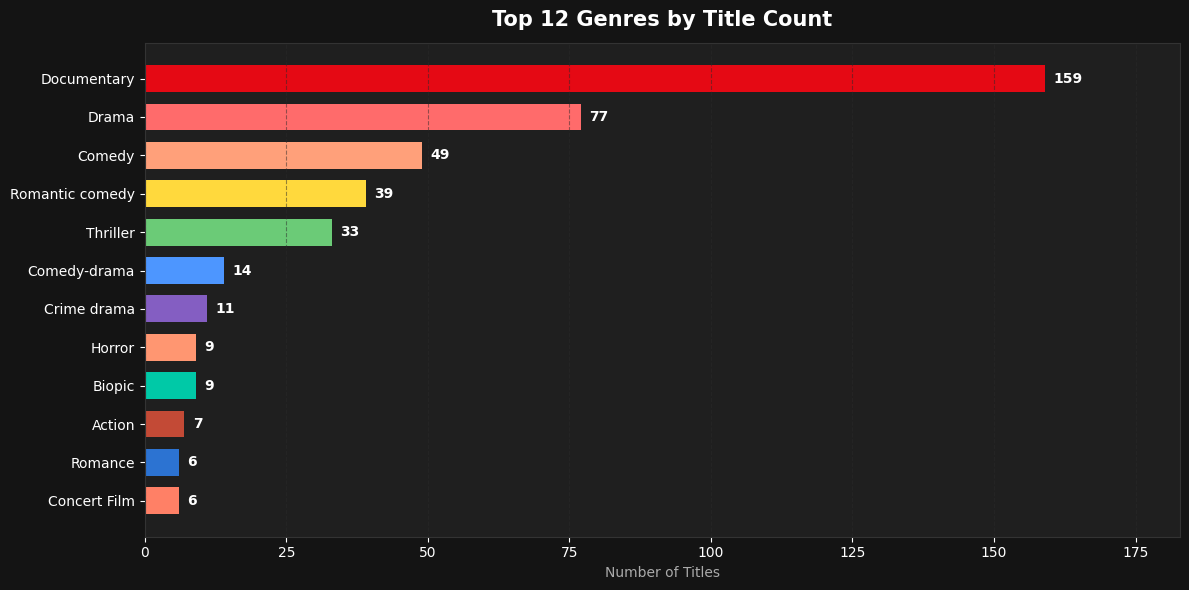

In [8]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
genre_counts = df['genre'].value_counts().head(12)
bars = ax.barh(genre_counts.index[::-1], genre_counts.values[::-1],
               color=GENRE_PALETTE[:12][::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10, color=TEXT_WHITE, fontweight='bold')
ax.set_title('Top 12 Genres by Title Count', fontsize=15, fontweight='bold',
             color=TEXT_WHITE, pad=12)
ax.set_xlabel('Number of Titles', color=TEXT_GRAY)
ax.set_xlim(0, genre_counts.max() * 1.15)
ax.tick_params(colors=TEXT_WHITE)
ax.grid(axis='x')
plt.tight_layout()
plt.show()

### Chart 2 · Language Distribution (Pie)

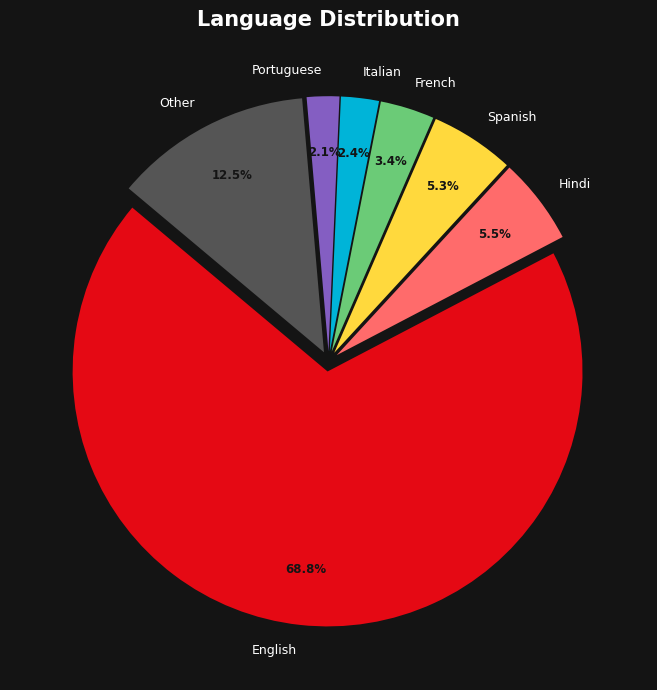

In [9]:
fig, ax = plt.subplots(figsize=(8, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)
lang_counts = df['language'].value_counts()
top_langs = lang_counts.head(6)
other_count = lang_counts.iloc[6:].sum()
pie_data   = list(top_langs.values) + [other_count]
pie_labels = list(top_langs.index)  + ['Other']
pie_colors = [NETFLIX_RED,'#FF6B6B','#FFD93D','#6BCB77',TEAL,'#845EC2','#555555']
wedges, texts, autotexts = ax.pie(
    pie_data, labels=pie_labels, autopct='%1.1f%%',
    colors=pie_colors, explode=[0.04]*7, startangle=140,
    pctdistance=0.78, textprops={'color': TEXT_WHITE, 'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(8.5); at.set_color(NETFLIX_BLACK); at.set_fontweight('bold')
ax.set_title('Language Distribution', fontsize=15, fontweight='bold',
             color=TEXT_WHITE, pad=12)
plt.tight_layout()
plt.show()

### Chart 3 · Titles Added Per Year (2014–2021)

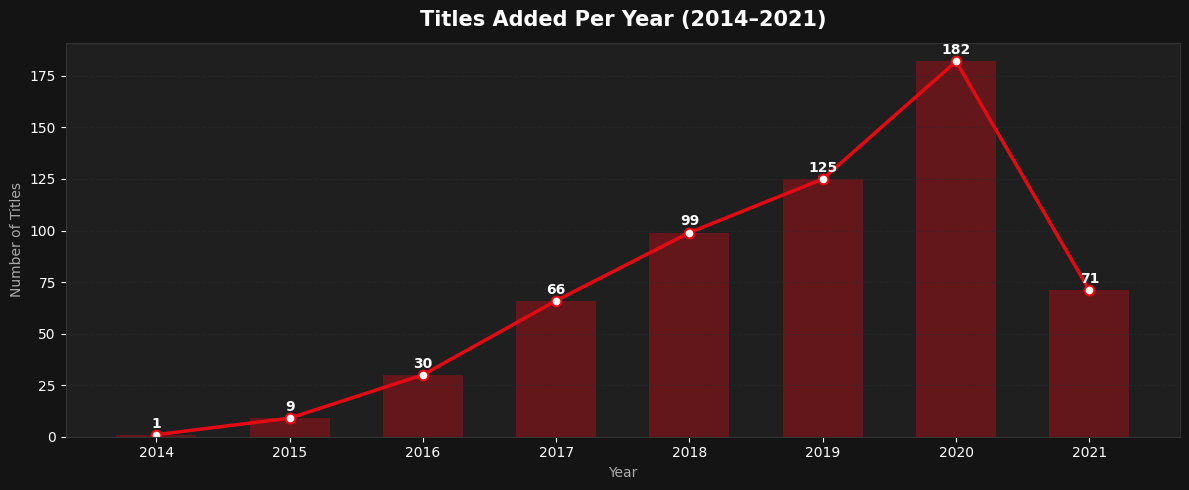

In [10]:
fig, ax = plt.subplots(figsize=(12, 5), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
yearly = df.groupby('year').size().reset_index(name='count')
ax.bar(yearly['year'], yearly['count'], color=NETFLIX_RED, alpha=0.35, width=0.6, edgecolor='none')
ax.plot(yearly['year'], yearly['count'], color=NETFLIX_RED, linewidth=2.5,
        marker='o', markersize=7, markerfacecolor=TEXT_WHITE,
        markeredgecolor=NETFLIX_RED, markeredgewidth=1.5)
for _, row in yearly.iterrows():
    ax.text(row['year'], row['count'] + 2, str(int(row['count'])),
            ha='center', va='bottom', fontsize=10, color=TEXT_WHITE, fontweight='bold')
ax.set_title('Titles Added Per Year (2014–2021)', fontsize=15, fontweight='bold',
             color=TEXT_WHITE, pad=12)
ax.set_xlabel('Year', color=TEXT_GRAY)
ax.set_ylabel('Number of Titles', color=TEXT_GRAY)
ax.set_xticks(yearly['year'])
ax.tick_params(colors=TEXT_WHITE)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### Chart 4 · IMDb Score Distribution

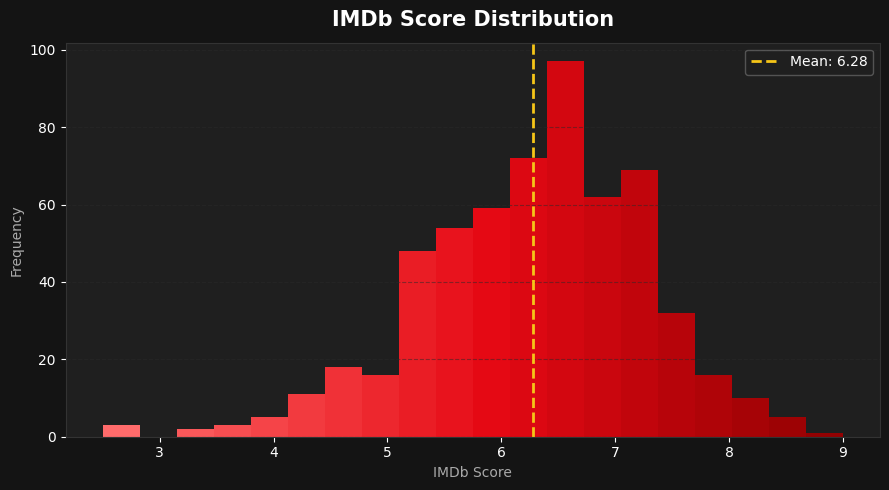

In [11]:
fig, ax = plt.subplots(figsize=(9, 5), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
cmap_red = LinearSegmentedColormap.from_list('nf', ['#FF6B6B', NETFLIX_RED, '#8B0000'])
n, bins, patches = ax.hist(df['imdb_score'], bins=20, edgecolor='none')
for i, patch in enumerate(patches):
    patch.set_facecolor(cmap_red(i / len(patches)))
mean_score = df['imdb_score'].mean()
ax.axvline(mean_score, color=GOLD, linewidth=2, linestyle='--', label=f'Mean: {mean_score:.2f}')
ax.legend(fontsize=10, framealpha=0.3)
ax.set_title('IMDb Score Distribution', fontsize=15, fontweight='bold',
             color=TEXT_WHITE, pad=12)
ax.set_xlabel('IMDb Score', color=TEXT_GRAY)
ax.set_ylabel('Frequency', color=TEXT_GRAY)
ax.tick_params(colors=TEXT_WHITE)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### Chart 5 · Average IMDb Score by Genre

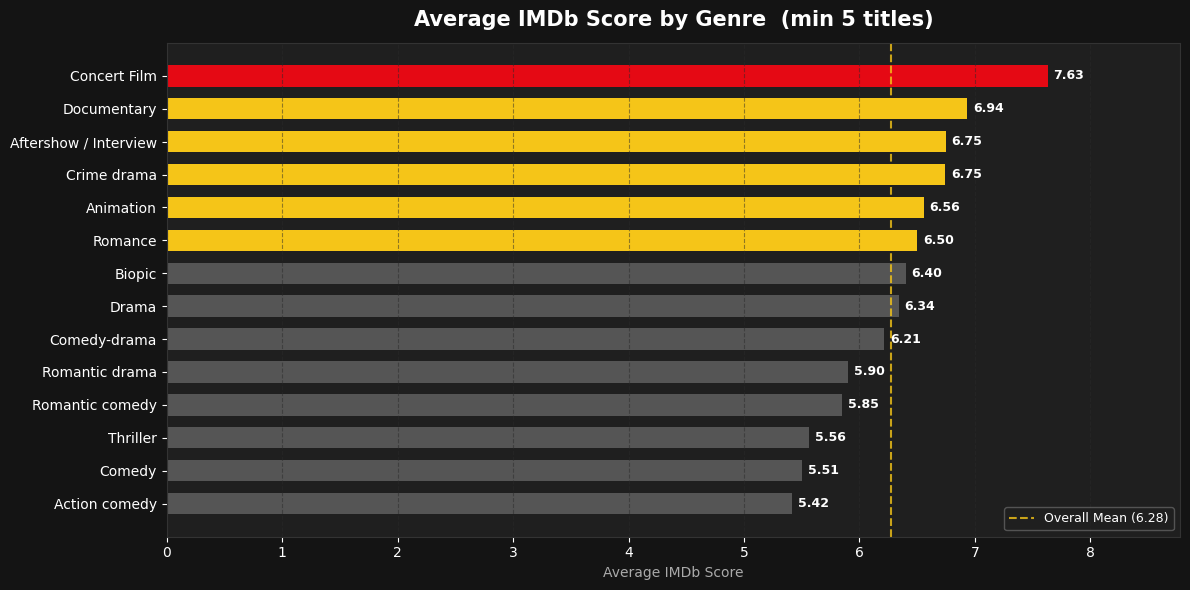

In [12]:
fig, ax = plt.subplots(figsize=(12, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
genre_score = (df.groupby('genre')['imdb_score']
                 .agg(['mean','count'])
                 .query('count >= 5')
                 .sort_values('mean', ascending=True)
                 .tail(14))
colors_score = [NETFLIX_RED if v >= 7.0 else (GOLD if v >= 6.5 else '#555555')
                for v in genre_score['mean']]
hbars = ax.barh(genre_score.index, genre_score['mean'],
                color=colors_score, edgecolor='none', height=0.65)
ax.axvline(mean_score, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8,
           label=f'Overall Mean ({mean_score:.2f})')
for bar, val in zip(hbars, genre_score['mean']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=9, color=TEXT_WHITE, fontweight='bold')
ax.set_xlim(0, genre_score['mean'].max() * 1.15)
ax.legend(fontsize=9, framealpha=0.3)
ax.set_title('Average IMDb Score by Genre  (min 5 titles)', fontsize=15,
             fontweight='bold', color=TEXT_WHITE, pad=12)
ax.set_xlabel('Average IMDb Score', color=TEXT_GRAY)
ax.tick_params(colors=TEXT_WHITE)
ax.grid(axis='x')
plt.tight_layout()
plt.show()

### Chart 6 · Runtime Distribution by Top 6 Genres (Boxplot)

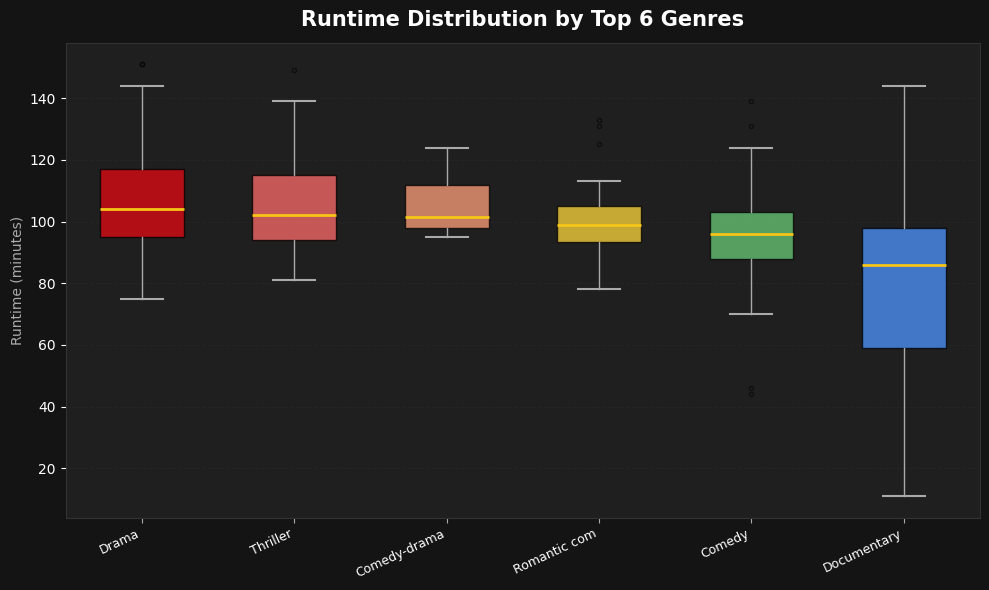

In [13]:
fig, ax = plt.subplots(figsize=(10, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
top6_genres  = df['genre'].value_counts().head(6).index
df_box       = df[df['genre'].isin(top6_genres)]
genre_order  = df_box.groupby('genre')['runtime'].median().sort_values(ascending=False).index
bp = ax.boxplot(
    [df_box[df_box['genre'] == g]['runtime'].values for g in genre_order],
    patch_artist=True, vert=True, widths=0.55,
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=TEXT_GRAY, linewidth=1),
    capprops=dict(color=TEXT_GRAY, linewidth=1.5),
    flierprops=dict(marker='o', color=NETFLIX_RED, markersize=3, alpha=0.5)
)
for patch, col in zip(bp['boxes'], GENRE_PALETTE[:6]):
    patch.set_facecolor(col); patch.set_alpha(0.75)
ax.set_xticklabels([g[:12] for g in genre_order], rotation=25, ha='right',
                   fontsize=9, color=TEXT_WHITE)
ax.set_title('Runtime Distribution by Top 6 Genres', fontsize=15,
             fontweight='bold', color=TEXT_WHITE, pad=12)
ax.set_ylabel('Runtime (minutes)', color=TEXT_GRAY)
ax.tick_params(axis='y', colors=TEXT_WHITE)
ax.grid(axis='y')
plt.tight_layout()
plt.show()

### Chart 7 · Content Volume Heatmap: Year × Genre

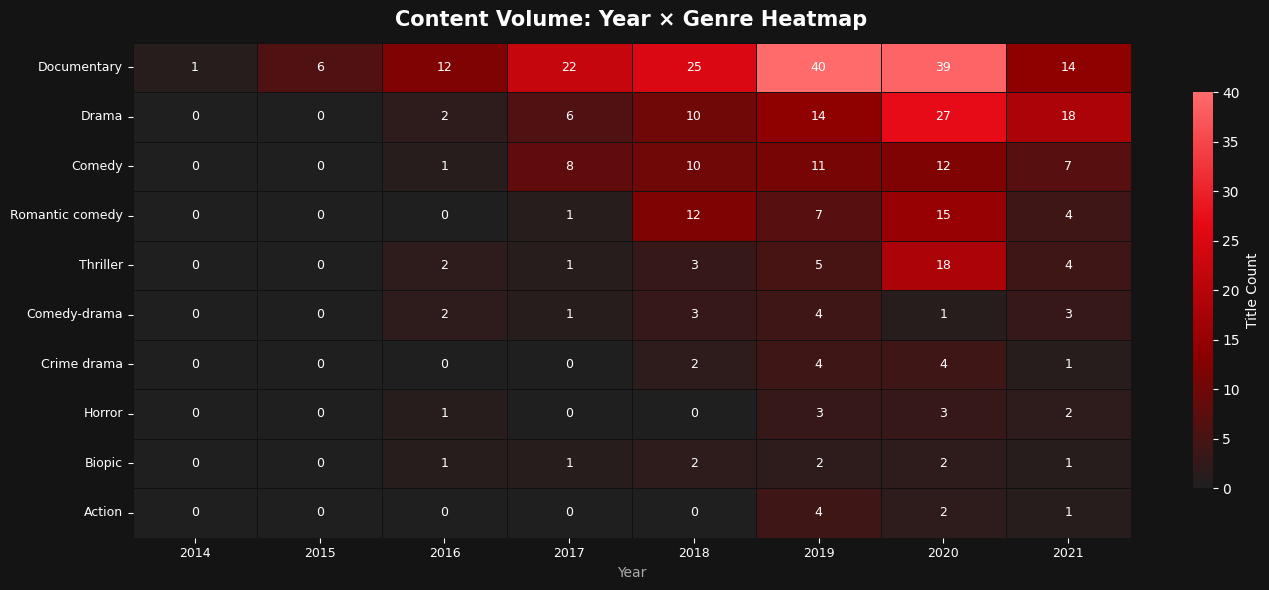

In [14]:
fig, ax = plt.subplots(figsize=(14, 6), facecolor=NETFLIX_BLACK)
ax.set_facecolor(DARK_GRAY)
top10_genres = df['genre'].value_counts().head(10).index
pivot = (df[df['genre'].isin(top10_genres)]
           .groupby(['year','genre'])
           .size()
           .unstack(fill_value=0))
pivot = pivot.reindex(columns=top10_genres)
cmap_hm = LinearSegmentedColormap.from_list('hm', [DARK_GRAY, '#8B0000', NETFLIX_RED, '#FF6B6B'])
sns.heatmap(pivot.T, ax=ax, cmap=cmap_hm, linewidths=0.5, linecolor='#111',
            annot=True, fmt='d', annot_kws={'size': 9, 'color': TEXT_WHITE},
            cbar_kws={'shrink': 0.8, 'label': 'Title Count'})
ax.set_title('Content Volume: Year × Genre Heatmap', fontsize=15,
             fontweight='bold', color=TEXT_WHITE, pad=12)
ax.set_xlabel('Year', color=TEXT_GRAY)
ax.set_ylabel('')
ax.tick_params(colors=TEXT_WHITE, labelsize=9)
ax.collections[0].colorbar.ax.yaxis.label.set_color(TEXT_WHITE)
ax.collections[0].colorbar.ax.tick_params(colors=TEXT_WHITE)
plt.tight_layout()
plt.show()

### Chart 8 · IMDb Score Quality Buckets (Donut)

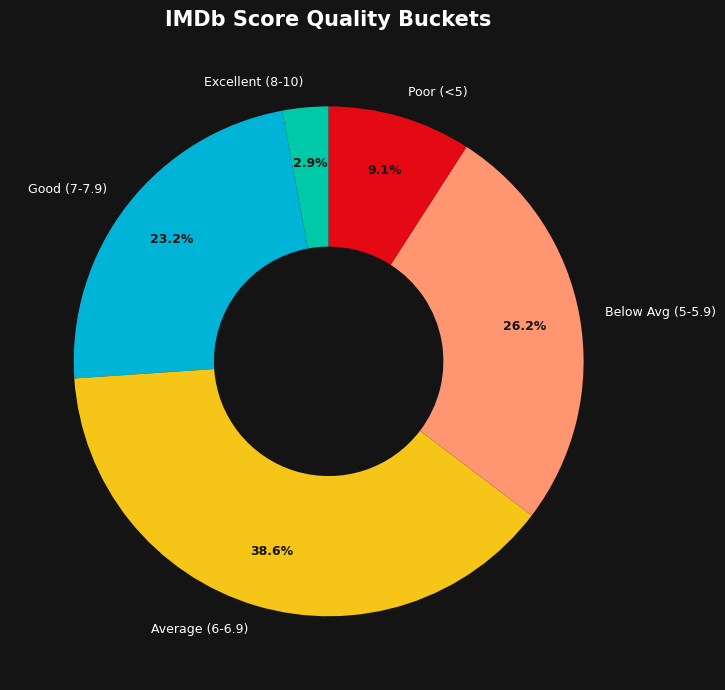

In [15]:
fig, ax = plt.subplots(figsize=(8, 7), facecolor=NETFLIX_BLACK)
ax.set_facecolor(NETFLIX_BLACK)
bucket_order  = ['Excellent (8-10)','Good (7-7.9)','Average (6-6.9)',
                  'Below Avg (5-5.9)','Poor (<5)']
bucket_colors = ['#00C9A7', TEAL, GOLD, '#FF9671', NETFLIX_RED]
bucket_counts = df['score_bucket'].value_counts().reindex(bucket_order, fill_value=0)
wedges, texts, autotexts = ax.pie(
    bucket_counts.values, labels=bucket_counts.index,
    autopct='%1.1f%%', colors=bucket_colors,
    startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55),
    textprops={'color': TEXT_WHITE, 'fontsize': 9}
)
for at in autotexts:
    at.set_fontsize(9); at.set_color(NETFLIX_BLACK); at.set_fontweight('bold')
ax.set_title('IMDb Score Quality Buckets', fontsize=15, fontweight='bold',
             color=TEXT_WHITE, pad=12)
plt.tight_layout()
plt.show()

## 🖼️ 6. Full Combined Dashboard
> Renders all 8 charts in one figure — ideal for export/sharing.

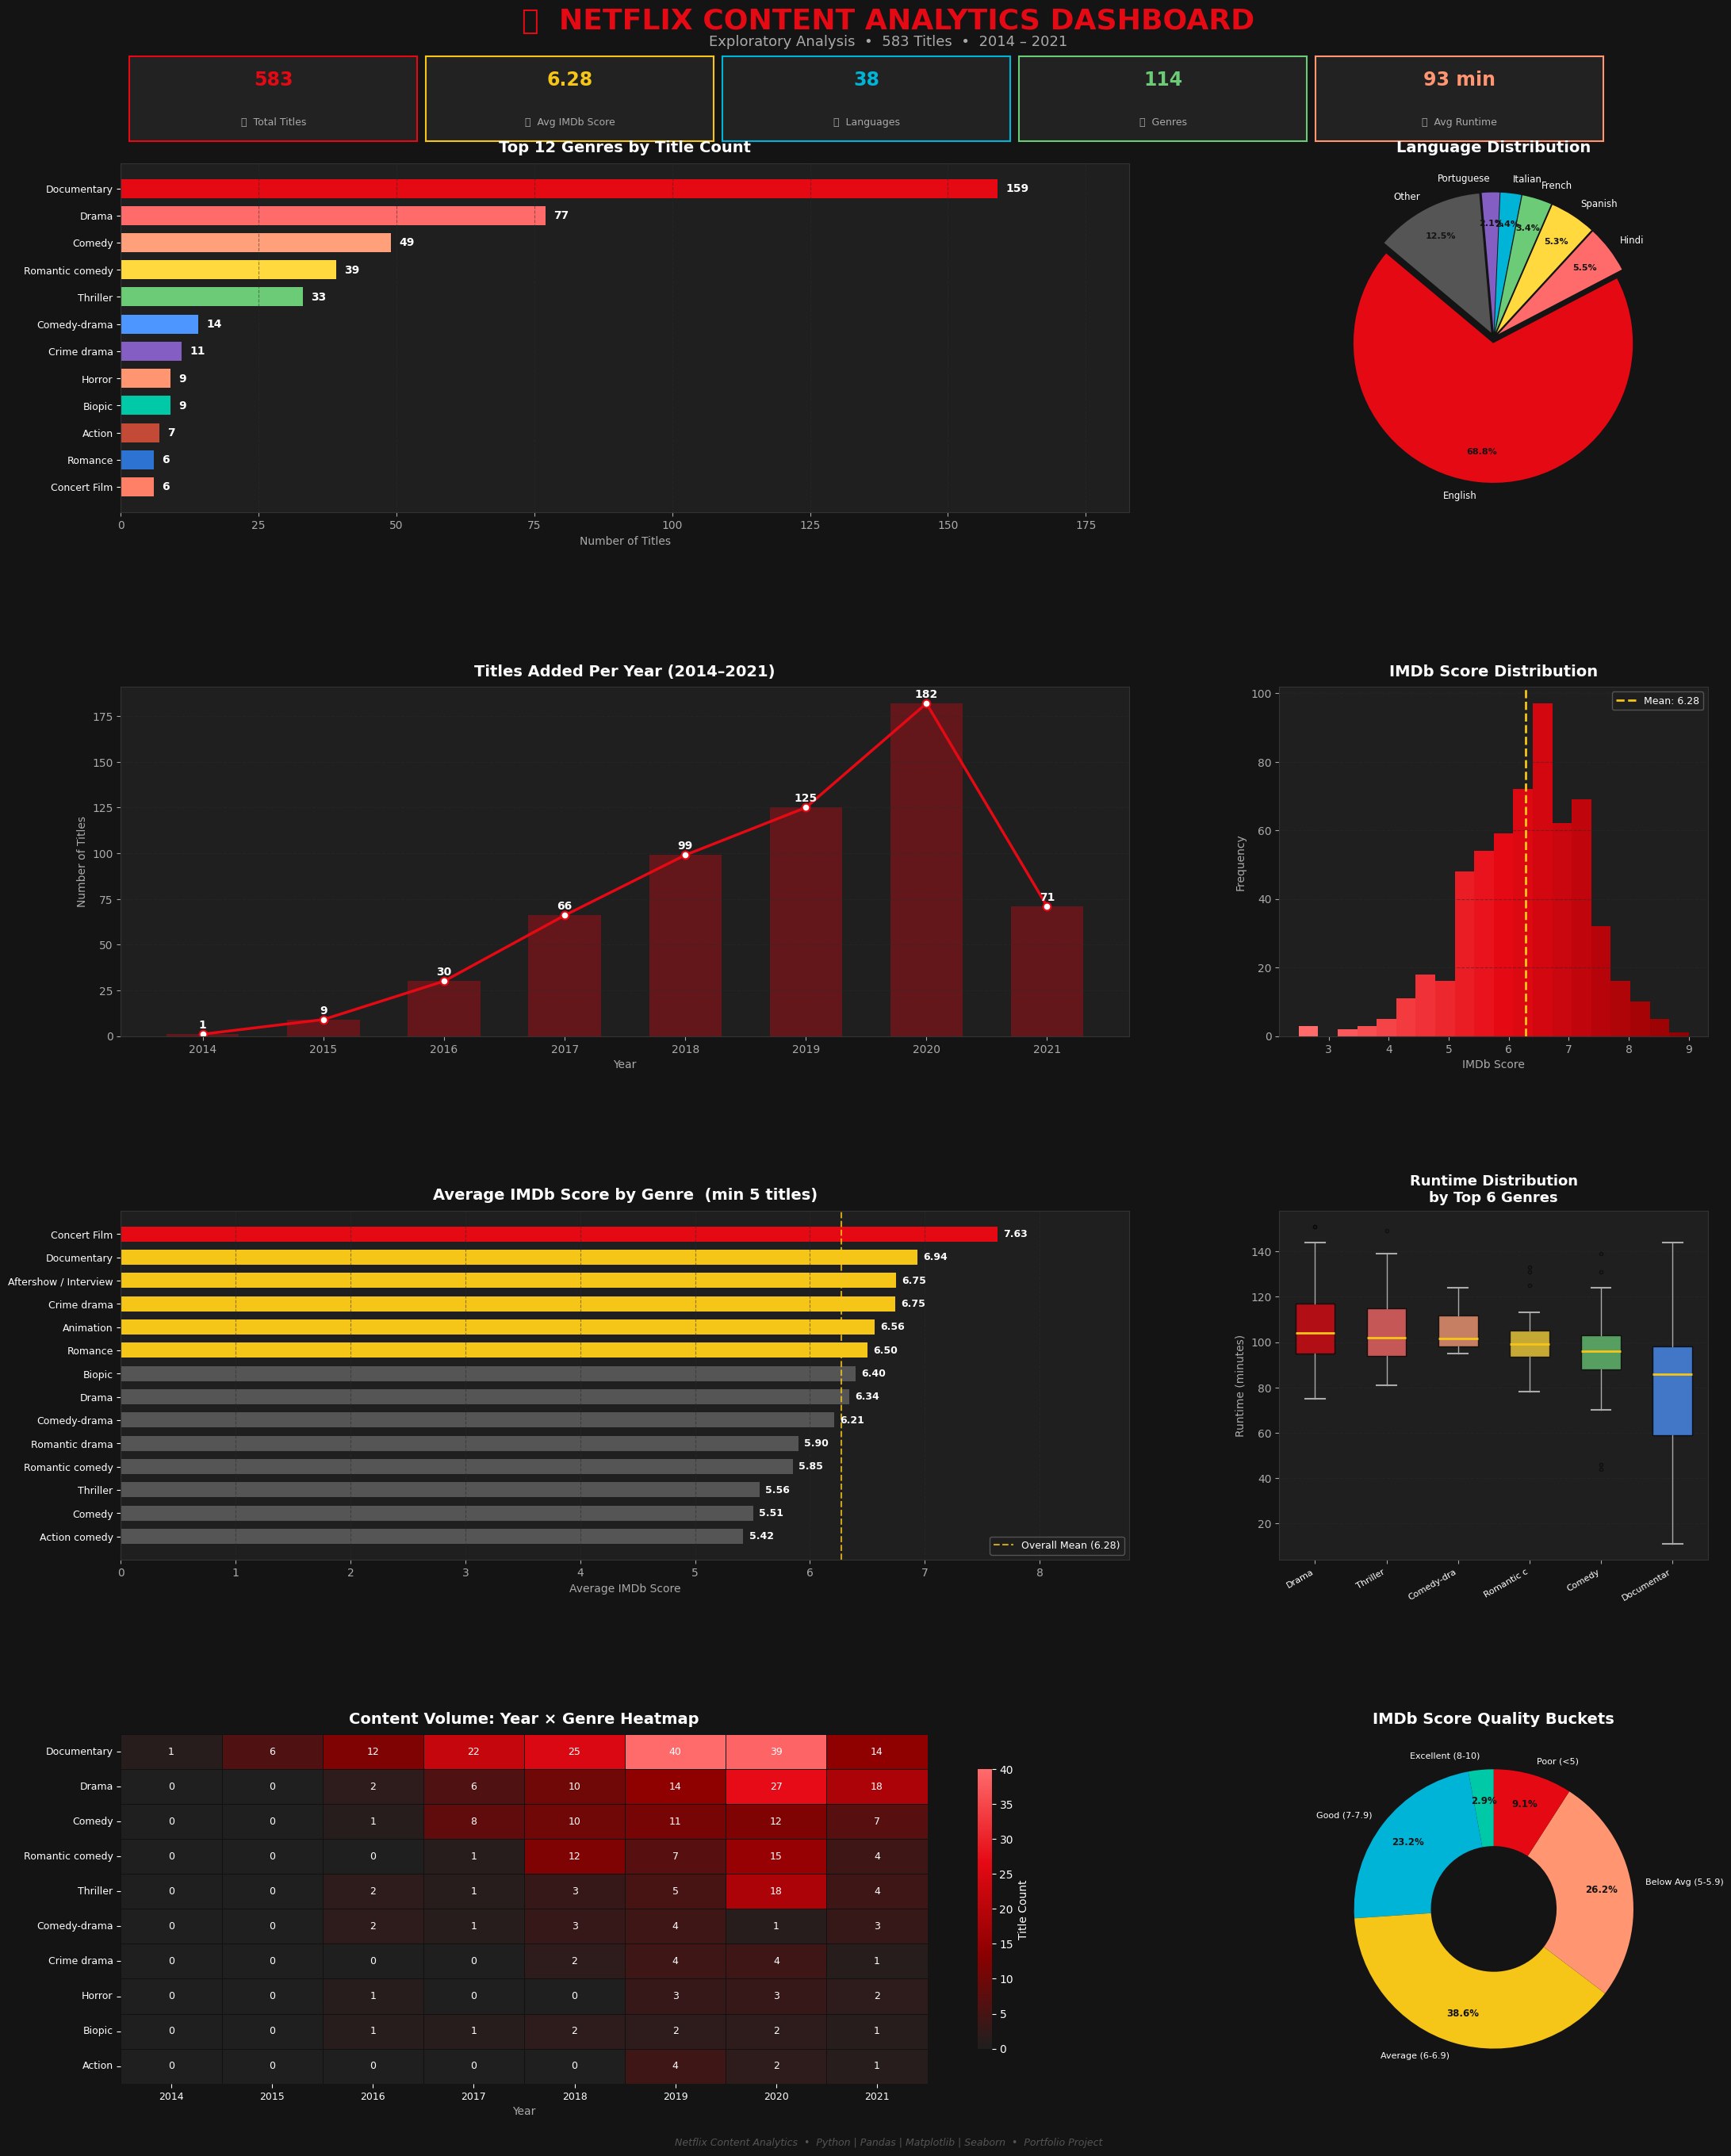

✅ Dashboard saved as netflix_dashboard.png


In [16]:
fig = plt.figure(figsize=(22, 28), facecolor=NETFLIX_BLACK)
fig.subplots_adjust(hspace=0.45, wspace=0.35, top=0.95, bottom=0.04, left=0.06, right=0.97)

fig.text(0.5, 0.975, '🎬  NETFLIX CONTENT ANALYTICS DASHBOARD',
         ha='center', va='top', fontsize=26, fontweight='bold', color=NETFLIX_RED)
fig.text(0.5, 0.963, f'Exploratory Analysis  •  {len(df):,} Titles  •  2014 – 2021',
         ha='center', va='top', fontsize=13, color=TEXT_GRAY)

kpi_y    = 0.915
kpi_data = [
    ('📽  Total Titles',   f'{len(df):,}',                    NETFLIX_RED),
    ('⭐  Avg IMDb Score', f'{df["imdb_score"].mean():.2f}',   GOLD),
    ('🌍  Languages',      f'{df["language"].nunique()}',       TEAL),
    ('🎭  Genres',         f'{df["genre"].nunique()}',          '#6BCB77'),
    ('⏱  Avg Runtime',    f'{df["runtime"].mean():.0f} min',   '#FF9671'),
]
for (label, val, col), x in zip(kpi_data, [0.065, 0.235, 0.405, 0.575, 0.745]):
    ax_kpi = fig.add_axes([x, kpi_y, 0.165, 0.038])
    ax_kpi.set_facecolor(CARD_BG)
    for sp in ax_kpi.spines.values(): sp.set_edgecolor(col); sp.set_linewidth(1.5)
    ax_kpi.set_xticks([]); ax_kpi.set_yticks([])
    ax_kpi.text(0.5, 0.72, val,   ha='center', va='center', fontsize=17,
                fontweight='bold', color=col, transform=ax_kpi.transAxes)
    ax_kpi.text(0.5, 0.22, label, ha='center', va='center', fontsize=9,
                color=TEXT_GRAY, transform=ax_kpi.transAxes)

gs = gridspec.GridSpec(4, 3, figure=fig, top=0.905, bottom=0.04,
                       hspace=0.50, wspace=0.35, left=0.06, right=0.97)

# --- Chart 1: Top Genres ---
ax1 = fig.add_subplot(gs[0, :2])
genre_counts = df['genre'].value_counts().head(12)
bars = ax1.barh(genre_counts.index[::-1], genre_counts.values[::-1],
                color=GENRE_PALETTE[:12][::-1], edgecolor='none', height=0.7)
for bar, val in zip(bars, genre_counts.values[::-1]):
    ax1.text(bar.get_width()+1.5, bar.get_y()+bar.get_height()/2,
             str(val), va='center', fontsize=10, color=TEXT_WHITE, fontweight='bold')
ax1.set_title('Top 12 Genres by Title Count', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)
ax1.set_xlabel('Number of Titles', color=TEXT_GRAY, fontsize=10)
ax1.set_xlim(0, genre_counts.max()*1.15); ax1.grid(axis='x')
ax1.tick_params(axis='y', labelsize=9, colors=TEXT_WHITE)

# --- Chart 2: Language Pie ---
ax2 = fig.add_subplot(gs[0, 2])
lang_counts = df['language'].value_counts()
top_langs = lang_counts.head(6)
pie_data   = list(top_langs.values) + [lang_counts.iloc[6:].sum()]
pie_labels = list(top_langs.index)  + ['Other']
pie_colors = [NETFLIX_RED,'#FF6B6B','#FFD93D','#6BCB77',TEAL,'#845EC2','#555555']
_, _, ats = ax2.pie(pie_data, labels=pie_labels, autopct='%1.1f%%', colors=pie_colors,
                    explode=[0.04]*7, startangle=140, pctdistance=0.78,
                    textprops={'color': TEXT_WHITE, 'fontsize': 8.5})
for at in ats: at.set_fontsize(8); at.set_color(NETFLIX_BLACK); at.set_fontweight('bold')
ax2.set_title('Language Distribution', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)

# --- Chart 3: Yearly trend ---
ax3 = fig.add_subplot(gs[1, :2])
yearly = df.groupby('year').size().reset_index(name='count')
ax3.bar(yearly['year'], yearly['count'], color=NETFLIX_RED, alpha=0.35, width=0.6, edgecolor='none')
ax3.plot(yearly['year'], yearly['count'], color=NETFLIX_RED, linewidth=2.5,
         marker='o', markersize=7, markerfacecolor=TEXT_WHITE,
         markeredgecolor=NETFLIX_RED, markeredgewidth=1.5)
for _, row in yearly.iterrows():
    ax3.text(row['year'], row['count']+2, str(int(row['count'])),
             ha='center', va='bottom', fontsize=10, color=TEXT_WHITE, fontweight='bold')
ax3.set_title('Titles Added Per Year (2014–2021)', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)
ax3.set_xlabel('Year', color=TEXT_GRAY, fontsize=10); ax3.set_ylabel('Number of Titles', color=TEXT_GRAY, fontsize=10)
ax3.set_xticks(yearly['year']); ax3.grid(axis='y')

# --- Chart 4: IMDb Histogram ---
ax4 = fig.add_subplot(gs[1, 2])
cmap_red = LinearSegmentedColormap.from_list('nf', ['#FF6B6B', NETFLIX_RED, '#8B0000'])
n, bins, patches = ax4.hist(df['imdb_score'], bins=20, edgecolor='none')
for i, patch in enumerate(patches): patch.set_facecolor(cmap_red(i/len(patches)))
mean_score = df['imdb_score'].mean()
ax4.axvline(mean_score, color=GOLD, linewidth=2, linestyle='--', label=f'Mean: {mean_score:.2f}')
ax4.legend(fontsize=9, framealpha=0.3)
ax4.set_title('IMDb Score Distribution', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)
ax4.set_xlabel('IMDb Score', color=TEXT_GRAY, fontsize=10)
ax4.set_ylabel('Frequency', color=TEXT_GRAY, fontsize=10); ax4.grid(axis='y')

# --- Chart 5: Genre vs IMDb ---
ax5 = fig.add_subplot(gs[2, :2])
genre_score = (df.groupby('genre')['imdb_score'].agg(['mean','count'])
                 .query('count >= 5').sort_values('mean', ascending=True).tail(14))
colors_score = [NETFLIX_RED if v >= 7.0 else (GOLD if v >= 6.5 else '#555555') for v in genre_score['mean']]
hbars = ax5.barh(genre_score.index, genre_score['mean'], color=colors_score, edgecolor='none', height=0.65)
ax5.axvline(mean_score, color=GOLD, linewidth=1.5, linestyle='--', alpha=0.8, label=f'Overall Mean ({mean_score:.2f})')
for bar, val in zip(hbars, genre_score['mean']):
    ax5.text(bar.get_width()+0.05, bar.get_y()+bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9, color=TEXT_WHITE, fontweight='bold')
ax5.set_xlim(0, genre_score['mean'].max()*1.15); ax5.legend(fontsize=9, framealpha=0.3)
ax5.set_title('Average IMDb Score by Genre  (min 5 titles)', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)
ax5.set_xlabel('Average IMDb Score', color=TEXT_GRAY, fontsize=10)
ax5.grid(axis='x'); ax5.tick_params(axis='y', labelsize=9, colors=TEXT_WHITE)

# --- Chart 6: Runtime Boxplot ---
ax6 = fig.add_subplot(gs[2, 2])
top6_genres = df['genre'].value_counts().head(6).index
df_box = df[df['genre'].isin(top6_genres)]
genre_order = df_box.groupby('genre')['runtime'].median().sort_values(ascending=False).index
bp = ax6.boxplot([df_box[df_box['genre']==g]['runtime'].values for g in genre_order],
    patch_artist=True, vert=True, widths=0.55,
    medianprops=dict(color=GOLD, linewidth=2),
    whiskerprops=dict(color=TEXT_GRAY, linewidth=1),
    capprops=dict(color=TEXT_GRAY, linewidth=1.5),
    flierprops=dict(marker='o', color=NETFLIX_RED, markersize=3, alpha=0.5))
for patch, col in zip(bp['boxes'], GENRE_PALETTE[:6]): patch.set_facecolor(col); patch.set_alpha(0.75)
ax6.set_xticklabels([g[:10] for g in genre_order], rotation=30, ha='right', fontsize=8, color=TEXT_WHITE)
ax6.set_title('Runtime Distribution\nby Top 6 Genres', fontsize=13, fontweight='bold', color=TEXT_WHITE, pad=8)
ax6.set_ylabel('Runtime (minutes)', color=TEXT_GRAY, fontsize=10); ax6.grid(axis='y')

# --- Chart 7: Heatmap ---
ax7 = fig.add_subplot(gs[3, :2])
top10_genres = df['genre'].value_counts().head(10).index
pivot = df[df['genre'].isin(top10_genres)].groupby(['year','genre']).size().unstack(fill_value=0)
pivot = pivot.reindex(columns=top10_genres)
cmap_hm = LinearSegmentedColormap.from_list('hm', [DARK_GRAY, '#8B0000', NETFLIX_RED, '#FF6B6B'])
sns.heatmap(pivot.T, ax=ax7, cmap=cmap_hm, linewidths=0.5, linecolor='#111',
            annot=True, fmt='d', annot_kws={'size': 9, 'color': TEXT_WHITE},
            cbar_kws={'shrink': 0.8, 'label': 'Title Count'})
ax7.set_title('Content Volume: Year × Genre Heatmap', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)
ax7.set_xlabel('Year', color=TEXT_GRAY, fontsize=10); ax7.set_ylabel('')
ax7.tick_params(colors=TEXT_WHITE, labelsize=9)
ax7.collections[0].colorbar.ax.yaxis.label.set_color(TEXT_WHITE)
ax7.collections[0].colorbar.ax.tick_params(colors=TEXT_WHITE)

# --- Chart 8: Score Donut ---
ax8 = fig.add_subplot(gs[3, 2])
bucket_order  = ['Excellent (8-10)','Good (7-7.9)','Average (6-6.9)','Below Avg (5-5.9)','Poor (<5)']
bucket_colors = ['#00C9A7', TEAL, GOLD, '#FF9671', NETFLIX_RED]
bucket_counts = df['score_bucket'].value_counts().reindex(bucket_order, fill_value=0)
_, _, ats2 = ax8.pie(bucket_counts.values, labels=bucket_counts.index,
    autopct='%1.1f%%', colors=bucket_colors, startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.55), textprops={'color': TEXT_WHITE, 'fontsize': 8})
for at in ats2: at.set_fontsize(8.5); at.set_color(NETFLIX_BLACK); at.set_fontweight('bold')
ax8.set_title('IMDb Score Quality Buckets', fontsize=14, fontweight='bold', color=TEXT_WHITE, pad=10)

fig.text(0.5, 0.012,
         'Netflix Content Analytics  •  Python | Pandas | Matplotlib | Seaborn  •  Portfolio Project',
         ha='center', fontsize=9, color='#555555', style='italic')
plt.savefig('netflix_dashboard.png', dpi=160, bbox_inches='tight',
            facecolor=NETFLIX_BLACK, edgecolor='none')
plt.show()
print('✅ Dashboard saved as netflix_dashboard.png')

## 💡 7. Key Insights Summary

In [17]:
print('=' * 60)
print('   NETFLIX CONTENT ANALYSIS — KEY INSIGHTS')
print('=' * 60)

top_genre = df['genre'].value_counts().idxmax()
top_lang  = df['language'].value_counts().idxmax()
best_genre_score = (df.groupby('genre')['imdb_score']
                      .mean().sort_values(ascending=False).idxmax())
peak_year = df.groupby('year').size().idxmax()

print(f'\n📌 Total titles analysed : {len(df):,}')
print(f'📌 Dominant genre        : {top_genre} ({df["genre"].value_counts().iloc[0]} titles)')
print(f'📌 Dominant language     : {top_lang} ({df["language"].value_counts().iloc[0]} titles, {df["language"].value_counts().iloc[0]/len(df)*100:.1f}%)')
print(f'📌 Peak content year     : {peak_year} ({df.groupby("year").size().max()} titles)')
print(f'📌 Avg IMDb score        : {df["imdb_score"].mean():.2f}')
print(f'📌 Best-rated genre      : {best_genre_score}')
print(f'📌 Titles scoring < 6.0  : {(df["imdb_score"] < 6).sum()} ({(df["imdb_score"] < 6).mean()*100:.1f}%)')
print(f'📌 Avg runtime           : {df["runtime"].mean():.0f} min')
print('=' * 60)

   NETFLIX CONTENT ANALYSIS — KEY INSIGHTS

📌 Total titles analysed : 583
📌 Dominant genre        : Documentary (159 titles)
📌 Dominant language     : English (401 titles, 68.8%)
📌 Peak content year     : 2020 (182 titles)
📌 Avg IMDb score        : 6.28
📌 Best-rated genre      : Animation/Christmas/Comedy/Adventure
📌 Titles scoring < 6.0  : 206 (35.3%)
📌 Avg runtime           : 93 min


## ✅ 8. Recommendations

| # | Problem | Recommendation |
|---|---------|----------------|
| 1 | **Documentary overload (27%)** | Cap at 20%; invest in Action, Sci-Fi & Animation originals |
| 2 | **69% English content** | Double non-English productions (Hindi, Spanish, Korean) |
| 3 | **35% titles score < 6.0** | Enforce min 6.5 IMDb acquisition threshold |
| 4 | **Post-2019 content drop** | Maintain 120–150 new titles/year with a 12-month pipeline |

> 📁 **Outputs:** `netflix_dashboard.png` — full 8-chart dashboard saved to disk.